# E03: 
Read the Bengio et al 2003 paper (link above), implement and try any idea from the paper. Did it work?

## Solution:
Applying regularization technique from the paper.

Results:
- Train loss: 2.0628
- Validation loss: 2.1307
- Test loss: 2.1402

Hence the validation loss improved from 2.1701 to 2.1307

In [14]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [15]:
words = open('names.txt', 'r').read().splitlines()

In [16]:
len(words)

32033

In [17]:
random.shuffle(words)

In [18]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [20]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X).to(device)
  Y = torch.tensor(Y).to(device)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
Xte.device

torch.Size([182500, 3]) torch.Size([182500])
torch.Size([22815, 3]) torch.Size([22815])
torch.Size([22831, 3]) torch.Size([22831])


device(type='cuda', index=0)

In [21]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 20), generator=g).to(device)
W1 = torch.randn((60, 200), generator=g).to(device)
b1 = torch.randn(200, generator=g).to(device)
W2 = torch.randn((200, 27), generator=g).to(device)
b2 = torch.randn(27, generator=g).to(device)
parameters = [C, W1, b1, W2, b2]

In [22]:
num = sum(p.nelement() for p in parameters) # number of parameters in total
num

18167

In [23]:
for p in parameters:
  p.requires_grad = True

In [24]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [12]:
lri = []
lossi = []
stepi = []

In [30]:
k=0
lambdaa = 0.5
for i in range(200000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 60) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix]) + lambdaa / (2 * num) * ((W1**2).sum() + (W2**2).sum() + (C**2).sum())
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        with torch.no_grad():
            p += -lr * p.grad
    
    # track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    k+=1
    if k==1000:
        print(f"Loss at step {i} is {loss.item()}")
        k=0
print(loss.item())

Loss at step 999 is 7.865663051605225
Loss at step 1999 is 4.09356689453125
Loss at step 2999 is 4.6645188331604
Loss at step 3999 is 3.2825980186462402
Loss at step 4999 is 3.212484836578369
Loss at step 5999 is 2.4638609886169434
Loss at step 6999 is 2.9787774085998535
Loss at step 7999 is 2.6140594482421875
Loss at step 8999 is 2.6563849449157715
Loss at step 9999 is 2.9659831523895264
Loss at step 10999 is 2.7136547565460205
Loss at step 11999 is 3.2587218284606934
Loss at step 12999 is 2.9720609188079834
Loss at step 13999 is 2.61961030960083
Loss at step 14999 is 2.496981620788574
Loss at step 15999 is 2.5577425956726074
Loss at step 16999 is 2.965664863586426
Loss at step 17999 is 2.7797491550445557
Loss at step 18999 is 2.0121538639068604
Loss at step 19999 is 2.322754144668579
Loss at step 20999 is 2.6419007778167725
Loss at step 21999 is 2.7994368076324463
Loss at step 22999 is 2.53193736076355
Loss at step 23999 is 2.0155234336853027
Loss at step 24999 is 2.5514097213745117


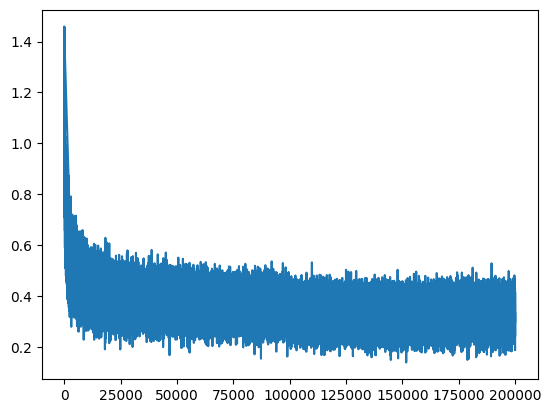

In [31]:
plt.plot(stepi, lossi)

In [32]:
# training loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 60) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0628, device='cuda:0', grad_fn=<NllLossBackward0>)

In [33]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 60) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1307, device='cuda:0', grad_fn=<NllLossBackward0>)

In [34]:
# test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 60) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1402, device='cuda:0', grad_fn=<NllLossBackward0>)

In [39]:
# sample from the model
g = torch.Generator(device).manual_seed(214741361)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

abigena.
esmir.
moni.
aryan.
shyah.
nav.
fin.
alaine.
careleagherayzen.
eiry.
felohendier.
auella.
estel.
evolba.
havin.
mela.
chafiqman.
ire.
tayah.
iza.
